Linear Regression gave a strong baseline (~92% test R²). Polynomial Regression improved the test R² to ~98%, indicating that nonlinear relationships are important in this dataset. I then experimented with Ridge, Lasso and Elastic Net to study regularization and coefficient control. These models did not produce a meaningful improvement over the linear baseline on this dataset, so their R² remained around 0.92.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("C:\\Users\\Pranjali\\OneDrive\\Desktop\\ml_algorithms\\linear_regression\\house_price_regression_synthetic.csv") 
df.head()

,area_sqft,built_up_area_sqft,carpet_area_sqft,bedrooms,bathrooms,rooms_total,living_area_sqft,house_age,distance_to_city_km,distance_to_school_km,parking_spaces,garden_color_code,street_light_count,house_paint_code,random_feature_1,house_price
0,2294,2005,1581,3,2,6,578,5.0,2.09,1.64,2,4,17,497,-0.8971,1089547.78
1,2842,2490,2131,6,4,8,786,5.4,2.97,10.61,2,12,22,931,-0.1030,1454544.70
2,2390,1984,1769,4,3,7,628,12.8,34.17,2.56,2,10,4,842,1.6655,912050.85
3,1138,1071,834,3,3,5,377,33.8,22.04,3.14,1,3,17,777,-1.6966,276901.20
4,983,635,574,3,2,6,279,9.1,7.73,3.74,2,10,22,577,1.8521,386747.03


In [3]:
df.shape

(1000, 16)

In [4]:
df.dtypes

area_sqft                  int64
built_up_area_sqft         int64
carpet_area_sqft           int64
bedrooms                   int64
bathrooms                  int64
rooms_total                int64
living_area_sqft           int64
house_age                float64
distance_to_city_km      float64
distance_to_school_km    float64
parking_spaces             int64
garden_color_code          int64
street_light_count         int64
house_paint_code           int64
random_feature_1         float64
house_price              float64
dtype: object

In [5]:
df.isnull().sum()

area_sqft                0
built_up_area_sqft       0
carpet_area_sqft         0
bedrooms                 0
bathrooms                0
rooms_total              0
living_area_sqft         0
house_age                0
distance_to_city_km      0
distance_to_school_km    0
parking_spaces           0
garden_color_code        0
street_light_count       0
house_paint_code         0
random_feature_1         0
house_price              0
dtype: int64

In [6]:
df.describe()

,area_sqft,built_up_area_sqft,carpet_area_sqft,bedrooms,bathrooms,rooms_total,living_area_sqft,house_age,distance_to_city_km,distance_to_school_km,parking_spaces,garden_color_code,street_light_count,house_paint_code,random_feature_1,house_price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,1713.032000,1537.313000,1240.322000,3.265000,2.326000,6.174000,522.325000,16.968000,14.975550,2.676680,1.254000,6.486000,16.406000,541.213000,0.028115,6.596854e+05
std,631.919013,574.339745,478.698197,1.228122,0.942663,1.643906,213.508551,11.259741,8.357196,1.775003,0.891223,3.361414,5.974517,252.236875,1.010538,3.771915e+05
min,550.000000,477.000000,394.000000,1.000000,1.000000,2.000000,150.000000,0.100000,1.060000,0.210000,0.000000,1.000000,0.000000,100.000000,-2.908600,1.221444e+05
25%,1284.000000,1136.000000,911.750000,2.000000,2.000000,5.000000,376.000000,8.600000,8.637500,1.367500,1.000000,4.000000,12.000000,328.000000,-0.655400,4.178177e+05
50%,1599.500000,1441.500000,1154.000000,3.000000,2.000000,6.000000,498.500000,14.600000,13.580000,2.270000,1.000000,7.000000,16.500000,538.500000,0.054450,5.699221e+05
75%,2013.250000,1832.500000,1462.500000,4.000000,3.000000,7.000000,631.000000,23.025000,19.552500,3.560000,2.000000,9.000000,20.000000,750.000000,0.738700,7.739911e+05
max,4500.000000,4291.000000,3481.000000,6.000000,5.000000,11.000000,1427.000000,60.000000,45.000000,12.000000,4.000000,12.000000,39.000000,999.000000,2.868200,2.957269e+06


In [7]:
df.var(axis=0).sort_values().head(5)

parking_spaces      0.794278
bathrooms           0.888613
random_feature_1    1.021188
bedrooms            1.508283
rooms_total         2.702426
dtype: float64

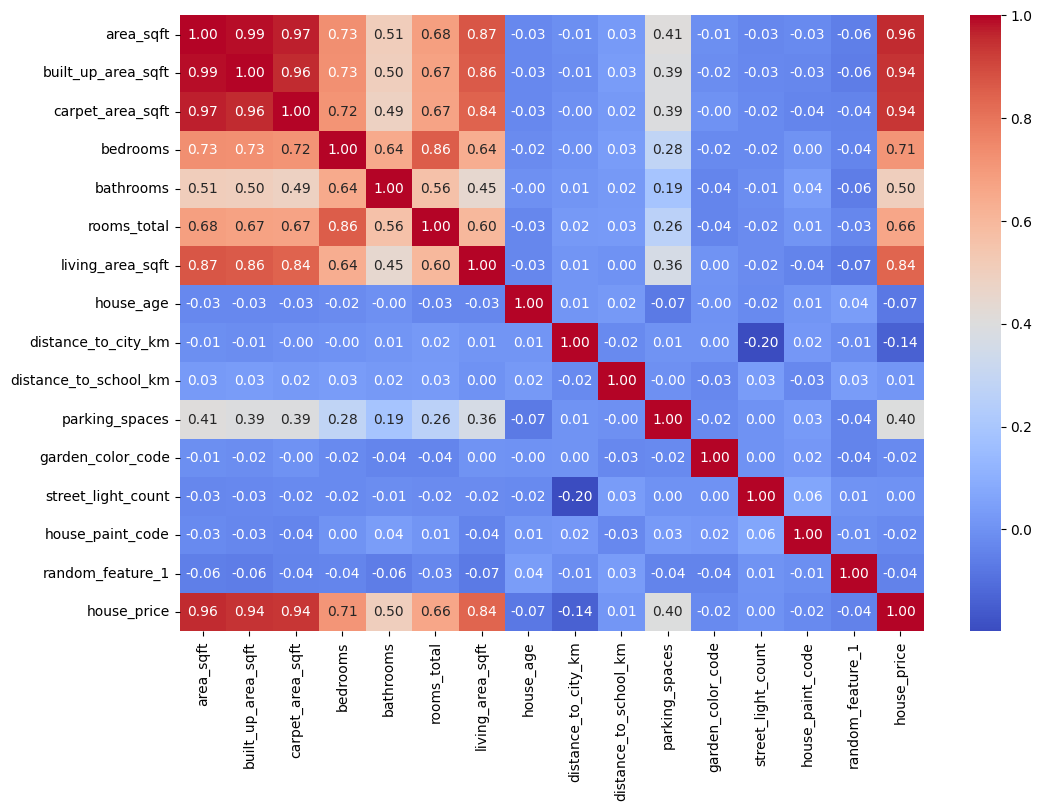

In [8]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

<Axes: xlabel='house_price', ylabel='Count'>

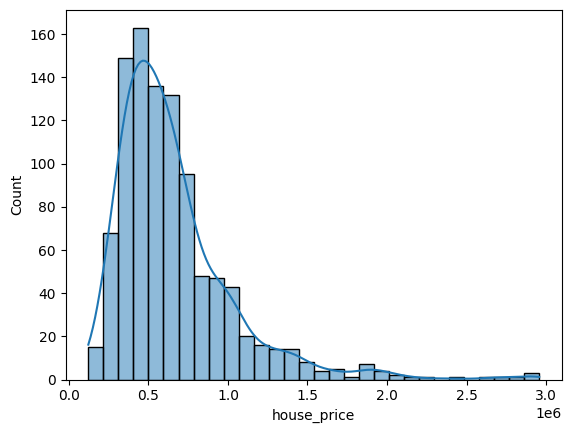

In [9]:
sns.histplot(data=df, x='house_price', bins=30, kde=True)

<Axes: xlabel='house_price'>

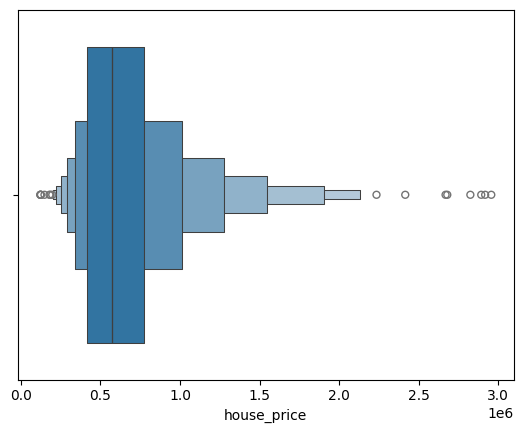

In [10]:
sns.boxenplot(data=df, x='house_price')

In [11]:
x=df.drop('house_price',axis=1)
y=df['house_price']

In [12]:
x.head()

,area_sqft,built_up_area_sqft,carpet_area_sqft,bedrooms,bathrooms,rooms_total,living_area_sqft,house_age,distance_to_city_km,distance_to_school_km,parking_spaces,garden_color_code,street_light_count,house_paint_code,random_feature_1
0,2294,2005,1581,3,2,6,578,5.0,2.09,1.64,2,4,17,497,-0.8971
1,2842,2490,2131,6,4,8,786,5.4,2.97,10.61,2,12,22,931,-0.1030
2,2390,1984,1769,4,3,7,628,12.8,34.17,2.56,2,10,4,842,1.6655
3,1138,1071,834,3,3,5,377,33.8,22.04,3.14,1,3,17,777,-1.6966
4,983,635,574,3,2,6,279,9.1,7.73,3.74,2,10,22,577,1.8521


In [13]:
y.head()

0    1089547.78
1    1454544.70
2     912050.85
3     276901.20
4     386747.03
Name: house_price, dtype: float64

In [14]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

In [15]:
#linear regression
from sklearn.linear_model import LinearRegression
model=LinearRegression(fit_intercept=True)
model.fit(x_train,y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [16]:
y_pred=model.predict(x_test)
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score,root_mean_squared_error
mean_squared_error(y_test,y_pred)



9979604098.700617

In [17]:
root_mean_squared_error(y_test,y_pred)


99897.96844130824

In [18]:
mean_absolute_error(y_test,y_pred)


68698.63454768267

In [19]:
r2_score(y_test,y_pred)
#test r2 score

0.9276170120812997

In [20]:
y_train_pred=model.predict(x_train)
r2_score(y_train,y_train_pred)
#train r2 score

0.9371696079470759

# using polynomial regression to cpauture non linearity in data

In [22]:
#polynomial regression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
poly=PolynomialFeatures(degree=2)
x_poly=poly.fit_transform(x_train)
xtest_poly=poly.transform(x_test)
model=LinearRegression()
model.fit(x_poly,y_train)



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [23]:
y_pred_poly=model.predict(xtest_poly)

In [24]:
mean_squared_error(y_test,y_pred_poly)

2199555652.1064

In [25]:
root_mean_squared_error(y_test,y_pred_poly)

46899.42059457025

In [26]:
r2_score(y_test,y_pred_poly)
#for testing dtaa

0.9840464202168444

In [27]:
#checking the traing r2 score
y_train_pred_poly=model.predict(x_poly)
r2_score(y_train,y_train_pred_poly)

0.9907209965154081

In [29]:
# comparing the gaps betwwn multiple and polynomial regression
# 1. lr (train=0.93)(test=0.92)
#2. plr (train=0.99)(test=0.98)

In [ ]:
#now here poylnomial regression given us high accuracy this tells us that non linaer is been
#present in data which the linaer model had not capured hence we used polynomial reg.

In [32]:
#ridge regression

In [49]:
from sklearn.linear_model import Ridge
ridge_model=Ridge(alpha=0.01)# we have to define alpha value for reidge that tells how strongly peanlize the lareg coefficents


In [50]:
ridge_model.fit(x_train,y_train)


,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",0.01
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [51]:
y_pred_ridge=ridge_model.predict(x_test)

In [52]:
mean_squared_error(y_test,y_pred_ridge)

9979590725.41488

In [53]:
root_mean_squared_error(y_test,y_pred_ridge)

99897.90150656259

In [54]:
r2_score(y_test,y_pred_ridge)

0.9276171090789731

In [55]:
#checking the traing r2 score
y_train_pred_ridge=ridge_model.predict(x_train)
r2_score(y_train,y_train_pred_ridge)

0.937169607946115

In [56]:
# using the lasso regression as ridge donot such imperoved the model accuracy

In [62]:
from sklearn.linear_model import Lasso
lasso_model=Lasso(alpha=0.1)
lasso_model.fit(x_train,y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [63]:
y_pred_lasso=lasso_model.predict(x_test)

In [64]:
mean_squared_error(y_test,y_pred_lasso)

9979592896.58219

In [65]:
root_mean_squared_error(y_test,y_pred_lasso)

99897.91237349351

In [66]:
r2_score(y_test,y_pred_lasso)

0.9276170933312966

In [67]:
y_pred_train_lasso=lasso_model.predict(x_train)
r2_score(y_train,y_pred_train_lasso)

0.9371696079462891

In [68]:
# using elastonet regression as lasso does not shown imapct on accuracy score

In [69]:
from sklearn.linear_model import ElasticNet
elastic_model=ElasticNet(alpha=0.1,l1_ratio=0.5)
elastic_model.fit(x_train,y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",0.1
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.5
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [70]:
y_pred_elastic=elastic_model.predict(x_test)

In [71]:
mean_squared_error(y_test,y_pred_elastic)

9934874598.522005

In [72]:
root_mean_squared_error(y_test,y_pred_elastic)

99673.84109445168

In [73]:
r2_score(y_test,y_pred_elastic)

0.927941439266889

In [74]:
y_pred_elastic_train=elastic_model.predict(x_train)
r2_score(y_train,y_pred_elastic_train)

0.9371583254233804

In [76]:
# 1. lr (train=0.93)(test=0.92)  - strong baseline model
#2. plr (train=0.99)(test=0.98)     - caputred non linear relationship
# 3. rr (train=0.93)(test=0.92)     - regualrization didint improve acuracy
# 4. lasr  (train=0.93)(test=0.92)  - no meannign ful improvement
# 5 .elastnet  (train=0.93)(test=0.92)  -no meannign ful improvement